In [184]:
#!pip install langchain langchain-openai pandas python-dotenv
# codeium, Deepseek R1, 
# Deepcode for finding the bugs

from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal, Annotated
from pydantic import BaseModel, Field
from langchain_google_genai import ChatGoogleGenerativeAI
import operator
from dotenv import load_dotenv

load_dotenv()
model = ChatGoogleGenerativeAI(model='gemini-2.5-flash-lite')
model_pro = ChatGoogleGenerativeAI(model='gemini-2.5-flash')

In [185]:
# write something
# AL will share content around that
# We will confirm that we are looking same thing
# AI will breakdown problem and list down action items
# Now AI will ask question to full fill the action items
# Finally AI will create a slef generate prompt
# AI will ask for user approval, if any more details required so user will share and AI re write the prompt
# AI will pass the prompt to get the answer
# For structure output:


In [186]:
class selfPrompt(TypedDict):
    topic : str
    content : str
    content_confirmation : Literal['yes','no']
    action_item : str
    askquestion : str
    retry : int 
    max_retry : int
    blog : str

class EvaluationSchema(BaseModel):

    feedback: str = Field(description='Detailed feedback for the essay')
    score: int = Field(description='Score out of 10', ge=0, le=10)
    content : str = Field(description='content should be in pointer and each new topic seperate by "-----"')

structured_model = model_pro.with_structured_output(EvaluationSchema)

# ----------------------------------------------------------

def TopicSuggestions(state : selfPrompt):

    URL = input('put your URL here: ')
    content = f""" suggest blog topics for URL: {URL} \n
                note: seperate each topic by "----" \n
                Only suggest topics no other information
                """
    output = model_pro.invoke(content).content
    print(output)
    topic = input('select your topic from above options: ')
    return {'topic':topic}


def WriteContent(state : selfPrompt):
    prompt = f"""You are a AI assitant and can you re-prompt below topic in 2-3 lines which will use to write a blog and also provide few options? \n topic : {state['topic']} 

    Note: options should be in simple 2-3 line \n
    There should be no extra content
    this prompt should have all possible details to write a blog, which AI can understand and produce a blog
    """
    
    output = model.invoke(prompt).content

    print(output)


def selectTopic(state : selfPrompt):
    aa = input("put your topic choice here: \n ")
    return {'content': aa}
    

def UserConfirmation(state : selfPrompt):
    print(state['content'])
    content_confirmation = input(f"\n Please confirm if above content is appropriate: Yes/No")

    aa = content_confirmation.lower()
    return {'content_confirmation' : aa}

    bb = state['retry'] + 1

    return {'retry': bb }

def ActionItem(state : selfPrompt):
    if state['content_confirmation'] == 'yes' and state['retry'] < state['max_retry']:
        
        prompt = f""" share essentails important point which we should consider while writing a blog for topic : {state['content']} \n
                Also cover all necessary points whihc required for a good blog writing
                """
        output = model.invoke(prompt).content

    return {'action_item' : output}

def AskQuestion(state : selfPrompt):
    
    prompt = f" Ask relavent questions from user using the action items provided below:\n {state['action_item']}  "
    text = model.invoke(prompt).content
    
    paragraph = re.split("\n",text.strip())
    qa_list = []
    for i in paragraph:
        #print(i)
        try:
            if i[0] in ['1', '2', '3', '4', '5', '6', '7', '8', '9']:
                j = i
                print(j)
                k = input("Write your answer: \n")
                qa_list.append(['Question :'+ j,'Answer :'+ k])
        except:
            pass 
    return {'askquestion': qa_list}


def WriteBlog(state : selfPrompt):
    prompt = f""" Write a fresh and new 200 words blog based on below pointer : \n
            topic : {state['content']} \n
            suggestion which you can consider while writing the blog : {state['action_item']} \n
            questions and Answers for additonal user information : {state['askquestion']}   
        """
    blog = model.invoke(prompt).content

    return {'blog': blog}



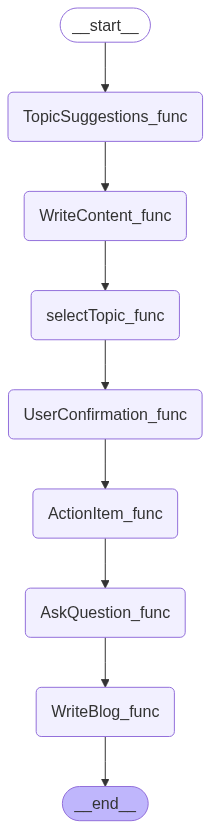

In [187]:
graph = StateGraph(selfPrompt)

graph.add_node('TopicSuggestions_func',TopicSuggestions)
graph.add_node('WriteContent_func',WriteContent)
graph.add_node('selectTopic_func',selectTopic)
graph.add_node('UserConfirmation_func',UserConfirmation)
graph.add_node('ActionItem_func',ActionItem)
graph.add_node('AskQuestion_func',AskQuestion)
graph.add_node('WriteBlog_func',WriteBlog)

graph.add_edge(START,'TopicSuggestions_func')
graph.add_edge('TopicSuggestions_func','WriteContent_func')
graph.add_edge('WriteContent_func','selectTopic_func')
#graph.add_edge('selectTopic_func',END)
graph.add_edge('selectTopic_func','UserConfirmation_func')
graph.add_edge('UserConfirmation_func','ActionItem_func')
graph.add_edge('ActionItem_func','AskQuestion_func')
graph.add_edge('AskQuestion_func','WriteBlog_func')
graph.add_edge('WriteBlog_func',END)

workflow = graph.compile()
workflow 

In [188]:
initial = {'retry' : 1 , 'max_retry':5 }
result = workflow.invoke(initial)

put your URL here:  blog on business education 


The ROI of a Business Degree: Is It Still Worth the Investment?
----
Beyond the MBA: Exploring Specialized Master's Programs in Business
----
How Business Education Prepares You for the Age of AI and Automation
----
The Essential Soft Skills Every Business Graduate Needs to Succeed
----
Navigating Online vs. In-Person Business Education: Which is Right for You?
----
Sustainable Business Practices: Why They're Now Core to Business Curricula
----
From Classroom to Boardroom: Applying Business Theory in the Real World
----
Executive Education: A Path to Leadership for Mid-Career Professionals
----
The Role of Global Awareness in Modern Business Education
----
Entrepreneurship in Business Schools: Fostering the Next Generation of Innovators


select your topic from above options:  Beyond the MBA: Exploring Specialized Master's Programs in Business


**Prompt:**

Craft a blog post exploring the value and diverse landscape of specialized master's programs in business as an alternative to the traditional MBA. Highlight specific fields, career advantages, and why a focused approach might be the smarter choice for ambitious professionals.

**Options:**

1.  **Focus on Career Niche:** Dive into how specialized master's degrees like Finance, Marketing, or Supply Chain Management equip professionals with deep expertise, leading to targeted career advancement and competitive advantages in specific industries.

2.  **MBA vs. Specialized Master's:** Compare and contrast the MBA with specialized master's programs, emphasizing which career goals and individual learning styles each degree path best serves, and when a focused approach offers greater ROI.

3.  **The Future of Business Education:** Examine the growing trend of specialized business master's, discussing how these programs are adapting to evolving industry demands and preparing gradu

put your topic choice here: 
  Craft a blog post exploring the value and diverse landscape of specialized master's programs in business as an alternative to the traditional MBA. Highlight specific fields, career advantages, and why a focused approach might be the smarter choice for ambitious professionals.


...

Write your answer: 
 mid-career professionals considering a change


2.  **What is the *single most important* takeaway you want your readers to have after reading your post?**


Write your answer: 
 how to do the business 


3.  **What is your ultimate goal for this blog post?** (e.g., drive traffic to a specific program page, generate leads for an admissions team, educate the market on the benefits of specialized master's, position your blog as an authority on graduate business education, etc.)


Write your answer: 
 educate the market on the benefits of specialized master's


In [189]:
result


{'topic': "Beyond the MBA: Exploring Specialized Master's Programs in Business",
 'content': "Craft a blog post exploring the value and diverse landscape of specialized master's programs in business as an alternative to the traditional MBA. Highlight specific fields, career advantages, and why a focused approach might be the smarter choice for ambitious professionals.",
 'content_confirmation': 'yes',
 'action_item': 'Here\'s a comprehensive guide to crafting a compelling blog post on specialized master\'s programs as an alternative to the traditional MBA, covering essential points for both the topic and good blog writing practices:\n\n## Crafting Your Blog Post: Specialized Master\'s vs. MBA\n\nThis topic is ripe for exploration because many ambitious professionals are seeking targeted career advancement. Your blog post should aim to inform, persuade, and ultimately guide them towards making an informed decision.\n\n### Essential Topic Points to Cover:\n\n**I. Introduction: Setting th